In [1]:
import numpy as np
from environments.inventory_control import InventoryControlEnv
from function_approximation.linear_fa import LinearFA
from function_approximation.polynomial_fa_new import PolynomialFA
from utils import run_experiment, run_polynomial_sweep

In [2]:
# Environment Setup
env = InventoryControlEnv(M=49)

# Get state/action dimensions for FA
P, R = env.get_mdp_matrices()
n_states = P.shape[0]
n_actions = P.shape[1]

# Hyperparameters
gamma = 0.9
iters = 100
n_seeds = 10

print(f"Environment: Inventory Control")
print(f"States: {n_states}, Actions: {n_actions}")
print(f"Gamma: {gamma}, Iterations: {iters}, Seeds: {n_seeds}")

Environment: Inventory Control
States: 50, Actions: 50
Gamma: 0.9, Iterations: 100, Seeds: 10


## Section 1: Linear Function Approximation

Running 10 seeds for Linear FA...


CRPI: 100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


Plot saved to: plots/Linear_FA/RPI_vs_CRPI_Linear_FA_20260307_205207.png


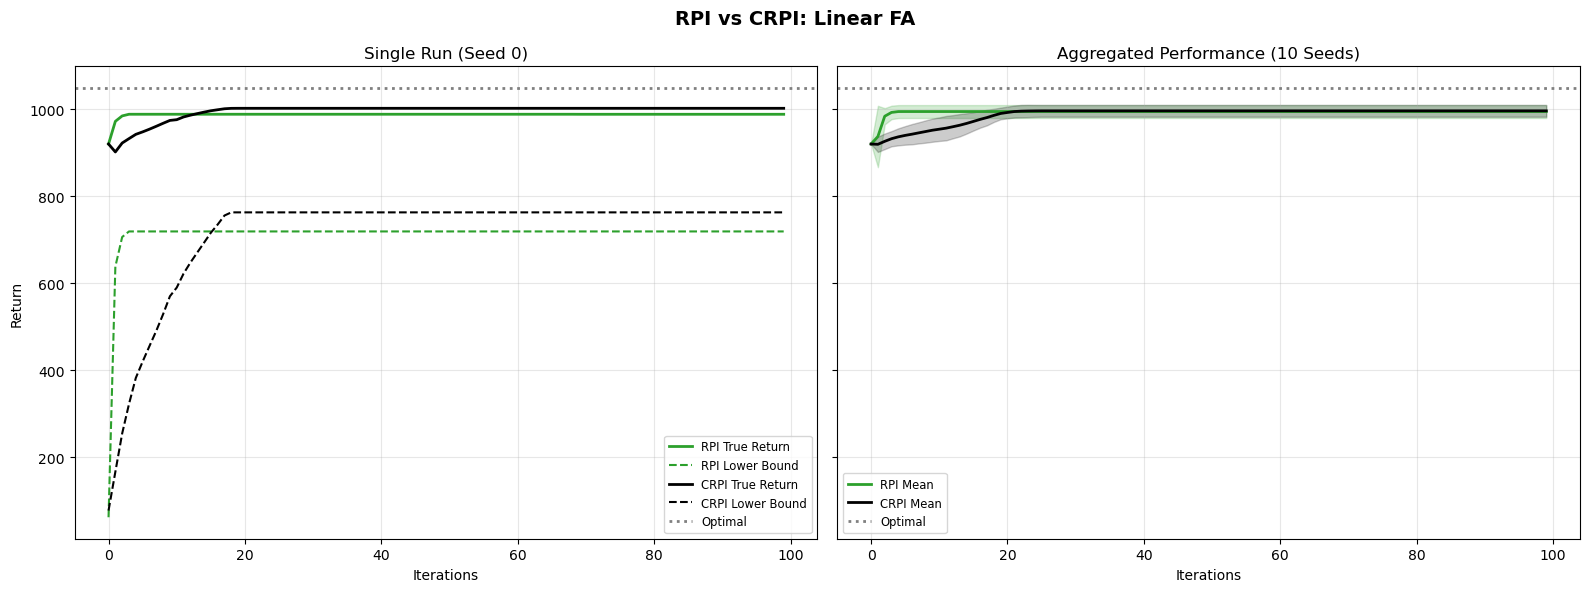

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,98374.4 ± 1479.1,994.76 ± 14.85
1,CRPI,97819.7 ± 1298.3,996.42 ± 13.56


In [3]:
# Linear FA Experiment
d_features = 75

linear_results = run_experiment(
    env=env,
    fa_class=LinearFA,
    gamma=gamma,
    iters=iters,
    n_seeds=n_seeds,
    fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': d_features},
    title_suffix="Linear FA",
    verbose=True
)

## Section 2: Polynomial Function Approximation


POLYNOMIAL DEGREE: 1


CRPI: 100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


Plot saved to: plots/polynomial_sweep/Polynomial_Degree_1_20260307_210037.png


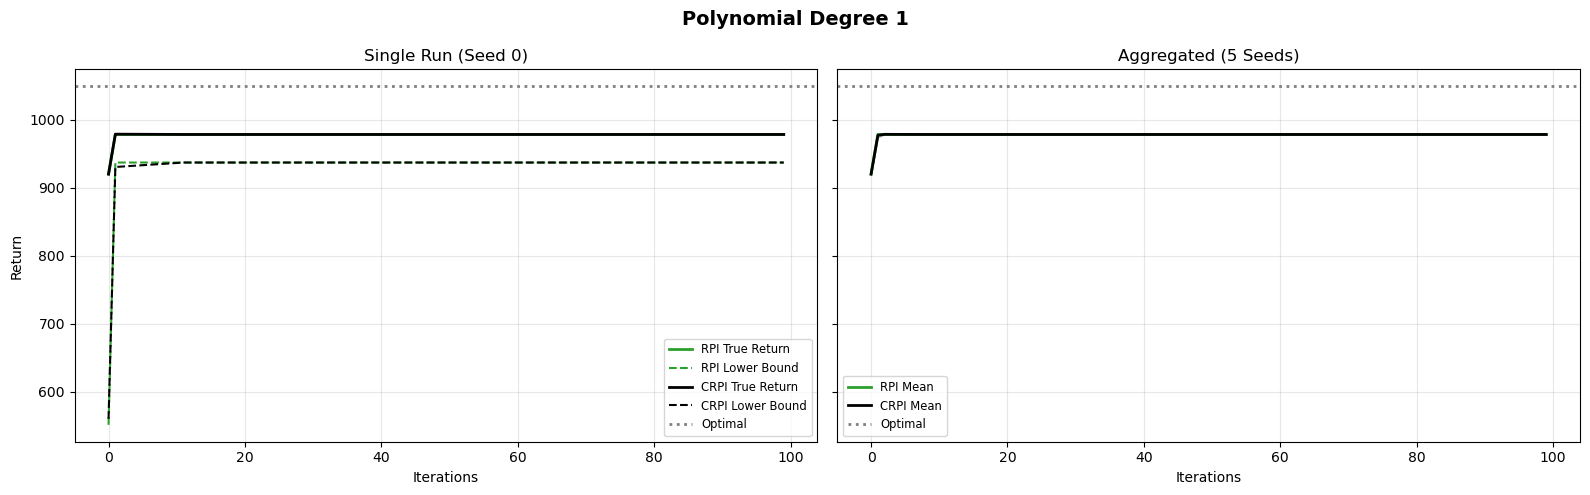

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,96834.3 ± 0.4,978.42 ± 0.00
1,CRPI,96833.5 ± 3.1,978.42 ± 0.00



POLYNOMIAL DEGREE: 2


CRPI: 100%|██████████| 100/100 [01:16<00:00,  1.30it/s]


Plot saved to: plots/polynomial_sweep/Polynomial_Degree_2_20260307_211036.png


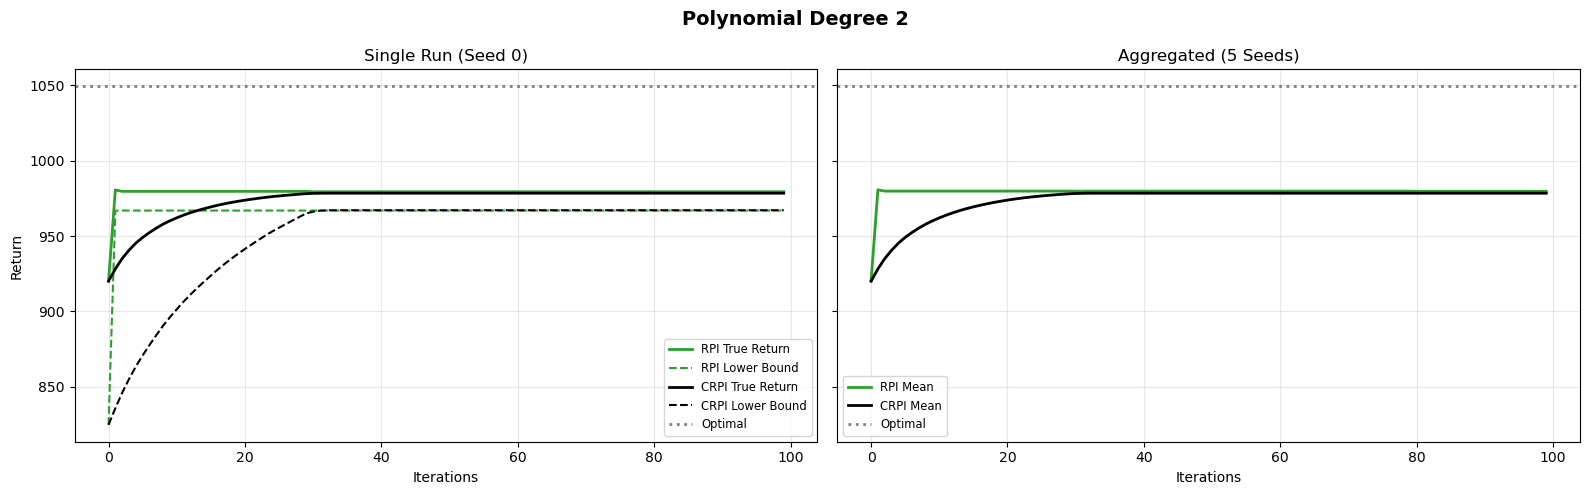

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,96966.9 ± 23.2,979.67 ± 0.23
1,CRPI,96428.4 ± 0.9,978.42 ± 0.00



SUMMARY ACROSS ALL DEGREES


,Degree,RPI Terminal,CRPI Terminal
0,1,978.417,978.417
1,2,979.670,978.417


In [4]:
# Polynomial FA Experiment - Sweep across degrees
# Mrudani do only 1,2,3 like you wanted to
# This is so you dnt miss to change this
degrees = [1, 2]
poly_n_seeds = 5  # Fewer seeds for polynomial sweep (more expensive)
d_features = 10

poly_results, poly_summary = run_polynomial_sweep(
    env=env,
    poly_fa_class=PolynomialFA,
    degrees=degrees,
    gamma=gamma,
    iters=iters,
    n_seeds=poly_n_seeds,
    base_fa_params={'n_states': n_states, 'n_actions': n_actions, 'd_features': d_features},
    verbose=True
)